# Nematic Pair Potential — Demo

This notebook demonstrates `align_angle.NematicPair`, an anisotropic pair
potential that attracts particles with **parallel or anti-parallel** body-axis
orientations (nematic symmetry):

$$U_{ij} = -\epsilon \, (\hat{n}_i \cdot \hat{n}_j)^2 \left(1 - \frac{r_{ij}^2}{r_c^2}\right)^2$$

where $\hat{n} = \mathrm{rotate}(q, \hat{x})$ is the body-frame x-axis.

We simulate **1,000 particles** in a compact box and observe spontaneous
**nematic ordering** — the emergence of a global preferred axis from
initially random orientations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hoomd
from hoomd import align_angle

print("HOOMD version:", hoomd.version.version)
device = hoomd.device.auto_select()
print("Device:", device)

HOOMD version: 5.3.1
Device: <hoomd.device.GPU object at 0x7ffa0df28470>


## 1. Create a snapshot with 1000 particles

We place 1000 particles on an FCC lattice and give each a random orientation.
The box is kept small so the density is high enough to promote nematic ordering.

In [2]:
N = 1000

# Use an FCC lattice that gives us at least N particles
n_unit = int(np.ceil((N / 4) ** (1 / 3)))  # FCC has 4 atoms per unit cell
snap = hoomd.Snapshot()

# FCC basis
basis = np.array([
    [0.0, 0.0, 0.0],
    [0.5, 0.5, 0.0],
    [0.5, 0.0, 0.5],
    [0.0, 0.5, 0.5],
])

positions = []
for ix in range(n_unit):
    for iy in range(n_unit):
        for iz in range(n_unit):
            for b in basis:
                positions.append([ix + b[0], iy + b[1], iz + b[2]])
positions = np.array(positions[:N])

# Scale so mean nearest-neighbour distance ~ 1.2 sigma
a = 1.2 * np.sqrt(2)  # FCC nearest-neighbour = a/sqrt(2)
positions *= a
positions -= positions.mean(axis=0)

L = n_unit * a
snap.configuration.box = [L, L, L, 0, 0, 0]
snap.particles.N = N
snap.particles.types = ["A"]
snap.particles.typeid[:] = 0
snap.particles.position[:] = positions

# Random orientations (unit quaternions)
rng = np.random.default_rng(42)
u = rng.normal(size=(N, 4))
u /= np.linalg.norm(u, axis=1, keepdims=True)
snap.particles.orientation[:] = u

# Needed for rotational integration
snap.particles.moment_inertia[:] = [1.0, 1.0, 1.0]

print(f"N = {N}, box L = {L:.2f}, number density = {N / L**3:.3f}")
print(f"Positions shape: {snap.particles.position.shape}")
print(f"Orientations shape: {snap.particles.orientation.shape}")

N = 1000, box L = 11.88, number density = 0.597
Positions shape: (1000, 3)
Orientations shape: (1000, 4)


## 2. Set up the simulation

We combine:
- **WCA** (Weeks–Chandler–Andersen) repulsion for excluded volume
- **NematicPair** attraction: $U = -\varepsilon\,(\hat n_i \cdot \hat n_j)^2\,(1 - r^2/r_c^2)^2$

A Langevin thermostat controls temperature. We set `integrate_rotational_dof = True`
so orientations respond to the nematic torques.

In [3]:
sim = hoomd.Simulation(device=device, seed=12345)
sim.create_state_from_snapshot(snap)

# --- Forces ---
# 1) WCA repulsion (LJ with r_cut = 2^(1/6) sigma)
cell = hoomd.md.nlist.Cell(buffer=0.4)
wca = hoomd.md.pair.LJ(nlist=cell, default_r_cut=2 ** (1.0 / 6.0), mode="shift")
wca.params[("A", "A")] = dict(epsilon=1.0, sigma=1.0)

# 2) Nematic pair attraction
r_cut_nematic = 2.5
nematic = align_angle.NematicPair(nlist=cell, default_r_cut=r_cut_nematic)
nematic.params[("A", "A")] = dict(epsilon=4.0)

# --- Integrator ---
langevin = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=1.0)
integrator = hoomd.md.Integrator(dt=0.005, methods=[langevin], forces=[wca, nematic])
integrator.integrate_rotational_dof = True
sim.operations.integrator = integrator

print("Forces:", [f.__class__.__name__ for f in integrator.forces])
print("Rotational DOF:", integrator.integrate_rotational_dof)

Forces: ['LJ', 'NematicPair']
Rotational DOF: True


## 3. Equilibrate & measure the nematic order parameter

The **nematic order parameter** $S$ is the largest eigenvalue of the
tensor order parameter:

$$Q_{\alpha\beta} = \frac{1}{N}\sum_{i=1}^{N}\left(\frac{3}{2}\,n_{i,\alpha}\,n_{i,\beta} - \frac{1}{2}\,\delta_{\alpha\beta}\right)$$

$S = 0$ means isotropic; $S = 1$ means perfect alignment.

In [4]:
def quat_to_director(q):
    """Convert quaternion (w, x, y, z) to body-frame z-axis in lab frame."""
    w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    nx = 2 * (x * z + w * y)
    ny = 2 * (y * z - w * x)
    nz = 1 - 2 * (x**2 + y**2)
    return np.stack([nx, ny, nz], axis=-1)


def nematic_order_parameter(orientations):
    """Compute S from the Q-tensor."""
    directors = quat_to_director(orientations)
    Q = np.zeros((3, 3))
    for alpha in range(3):
        for beta in range(3):
            Q[alpha, beta] = np.mean(
                1.5 * directors[:, alpha] * directors[:, beta]
                - 0.5 * (alpha == beta)
            )
    return np.max(np.linalg.eigvalsh(Q))


# --- Run and record S(t) ---
n_steps_total = 50_000
sample_period = 500
steps_list = []
S_list = []

for i in range(n_steps_total // sample_period):
    sim.run(sample_period)
    snap_now = sim.state.get_snapshot()
    ori = snap_now.particles.orientation
    S = nematic_order_parameter(ori)
    steps_list.append(sim.timestep)
    S_list.append(S)
    if (i + 1) % 20 == 0:
        print(f"  step {sim.timestep:>7d}  S = {S:.3f}")

steps_arr = np.array(steps_list)
S_arr = np.array(S_list)
print(f"\nFinal S = {S_arr[-1]:.3f}")

  step   10000  S = 0.268
  step   20000  S = 0.254
  step   30000  S = 0.263
  step   40000  S = 0.263
  step   50000  S = 0.271

Final S = 0.271


## 4. Plot the nematic order parameter over time

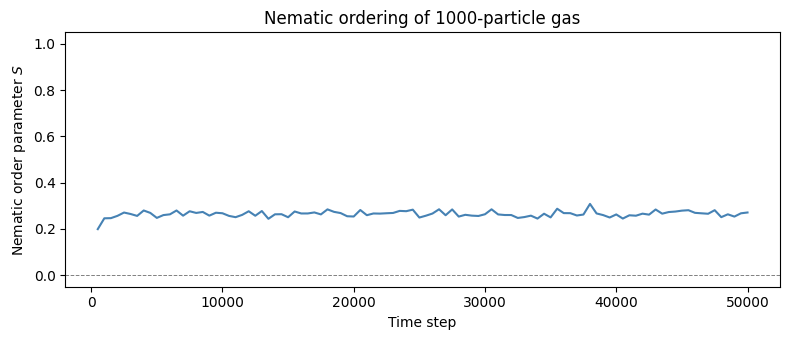

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(steps_arr, S_arr, lw=1.5, color="steelblue")
ax.set_xlabel("Time step")
ax.set_ylabel("Nematic order parameter $S$")
ax.set_ylim(-0.05, 1.05)
ax.axhline(0, color="gray", ls="--", lw=0.7)
ax.set_title("Nematic ordering of 1000-particle gas")
fig.tight_layout()
plt.show()

## 5. 3D visualization with Plotly

Each particle is drawn as a cone pointing along its director $\hat n$.
Colour encodes the alignment with the nematic director (eigenvector of the
largest eigenvalue of $Q$).

In [6]:
import plotly.graph_objects as go

# Final snapshot
snap_final = sim.state.get_snapshot()
pos = np.array(snap_final.particles.position)
ori = np.array(snap_final.particles.orientation)
directors = quat_to_director(ori)

# Compute nematic director (eigenvector of Q)
Q = np.zeros((3, 3))
for a in range(3):
    for b in range(3):
        Q[a, b] = np.mean(1.5 * directors[:, a] * directors[:, b] - 0.5 * (a == b))
eigvals, eigvecs = np.linalg.eigh(Q)
nematic_director = eigvecs[:, np.argmax(eigvals)]

# cos^2(theta) with nematic director — measures alignment
cos2 = (directors @ nematic_director) ** 2

# Draw cones
cone_len = 0.5
fig = go.Figure()
fig.add_trace(go.Cone(
    x=pos[:, 0], y=pos[:, 1], z=pos[:, 2],
    u=directors[:, 0], v=directors[:, 1], w=directors[:, 2],
    sizemode="absolute",
    sizeref=cone_len,
    colorscale="RdYlBu",
    cmin=0, cmax=1,
    colorbar=dict(title="cos²θ"),
    anchor="center",
    showscale=True,
))

L = snap_final.configuration.box[0]
fig.update_layout(
    scene=dict(
        xaxis=dict(range=[-L/2, L/2]),
        yaxis=dict(range=[-L/2, L/2]),
        zaxis=dict(range=[-L/2, L/2]),
        aspectmode="cube",
    ),
    title=f"Nematic gas — S = {S_arr[-1]:.3f}",
    width=700, height=700,
    margin=dict(l=0, r=0, t=40, b=0),
)
fig.show()

## 6. Distribution of pairwise alignment

Histogram of $|\hat n_i \cdot \hat n_j|$ for all neighbour pairs within the
nematic cutoff. In a nematic phase the distribution is sharply peaked near 1.

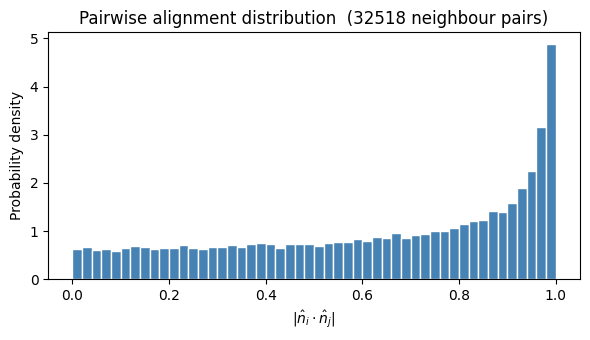

In [8]:
from scipy.spatial import cKDTree

L = snap_final.configuration.box[0]
# cKDTree needs coords in [0, L)
pos_shifted = pos % L
tree = cKDTree(pos_shifted, boxsize=L)
pairs = tree.query_pairs(r=r_cut_nematic, output_type="ndarray")

cos_ij = np.sum(directors[pairs[:, 0]] * directors[pairs[:, 1]], axis=1)
abs_cos_ij = np.abs(cos_ij)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(abs_cos_ij, bins=50, density=True, color="steelblue", edgecolor="white", lw=0.3)
ax.set_xlabel(r"$|\hat n_i \cdot \hat n_j|$")
ax.set_ylabel("Probability density")
ax.set_title(f"Pairwise alignment distribution  ({len(pairs)} neighbour pairs)")
fig.tight_layout()
plt.show()